In [1]:
import os
import glob
import zipfile
import pandas as pd
import gc

DATA_PATH = "/content/oulad"
os.makedirs(DATA_PATH, exist_ok=True)

!kaggle datasets download -d vjcalling/ouladdata -p /content/oulad

for z in glob.glob(f"{DATA_PATH}/*.zip"):
    with zipfile.ZipFile(z, "r") as f:
        f.extractall(DATA_PATH)

print("OULAD ready")

Dataset URL: https://www.kaggle.com/datasets/vjcalling/ouladdata
License(s): unknown
100% 64.0M/64.0M [00:00<00:00, 119MB/s] 

OULAD ready


In [2]:
# Load studentVle parts
vle_files = sorted(glob.glob(f"{DATA_PATH}/studentVle_*.csv"))

student_vle = pd.concat(
    [pd.read_csv(f) for f in vle_files],
    ignore_index=True
)

student_vle = student_vle.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

student_assessment = pd.read_csv(
    f"{DATA_PATH}/studentAssessment.csv"
)

vle = pd.read_csv(
    f"{DATA_PATH}/vle.csv"
)

print("student_vle:", student_vle.shape)
print("student_assessment:", student_assessment.shape)
print("vle:", vle.shape)

gc.collect()

student_vle: (10655280, 6)
student_assessment: (173912, 5)
vle: (6364, 6)


0

In [3]:
interaction = student_vle[
    [
        "id_student",
        "id_site",
        "date",
        "sum_click"
    ]
].rename(columns={
    "id_student": "user_id",
    "id_site": "resource_id",
    "date": "interaction_date",
    "sum_click": "click_count"
})

del student_vle
gc.collect()

print(interaction.shape)

(10655280, 4)


In [4]:
resource_info = vle[
    [
        "id_site",
        "activity_type"
    ]
].rename(columns={
    "id_site": "resource_id"
})

interaction = interaction.merge(
    resource_info,
    on="resource_id",
    how="left"
)

del resource_info
del vle
gc.collect()

print(interaction.shape)

(10655280, 5)


In [5]:
interaction = interaction.sort_values(
    ["user_id", "interaction_date"]
)

interaction["previous_resource"] = (
    interaction
    .groupby("user_id")["resource_id"]
    .shift(1)
)

interaction["next_resource"] = (
    interaction
    .groupby("user_id")["resource_id"]
    .shift(-1)
)

interaction["repeated_interaction"] = (
    interaction["resource_id"] ==
    interaction["previous_resource"]
).astype("int8")

interaction["future_rewatch"] = (
    interaction["resource_id"] ==
    interaction["next_resource"]
).astype("int8")

print(
    interaction["future_rewatch"].value_counts()
)

future_rewatch
0    9566851
1    1088429
Name: count, dtype: int64


In [6]:
quiz = student_assessment[
    [
        "id_student",
        "date_submitted",
        "score"
    ]
].rename(columns={
    "id_student": "user_id",
    "score": "quiz_score"
})

quiz = quiz.sort_values(
    ["user_id", "date_submitted"]
)

quiz["previous_quiz_score"] = (
    quiz
    .groupby("user_id")["quiz_score"]
    .shift(1)
)

quiz["score_change"] = (
    quiz["quiz_score"] -
    quiz["previous_quiz_score"]
)

gc.collect()

0

In [7]:
latest_quiz = (
    quiz
    .groupby("user_id")
    .tail(1)
    [
        [
            "user_id",
            "quiz_score",
            "previous_quiz_score",
            "score_change"
        ]
    ]
    .rename(columns={
        "quiz_score": "latest_quiz_score"
    })
)

print(latest_quiz.shape)

(23369, 4)


In [8]:
model_data = interaction.merge(
    latest_quiz,
    on="user_id",
    how="left"
)

model_data[
    [
        "latest_quiz_score",
        "previous_quiz_score",
        "score_change"
    ]
] = model_data[
    [
        "latest_quiz_score",
        "previous_quiz_score",
        "score_change"
    ]
].fillna(0)

del interaction
del quiz
del latest_quiz
del student_assessment
gc.collect()

print(model_data.shape)

(10655280, 12)


In [9]:
X = model_data[
    [
        "click_count",
        "repeated_interaction",
        "interaction_date",
        "latest_quiz_score",
        "previous_quiz_score",
        "score_change",
        "activity_type"
    ]
].copy()

y = model_data["future_rewatch"].copy()

X["interaction_week"] = (
    X["interaction_date"] // 7
)

X = X.drop(
    columns=["interaction_date"]
)

X = pd.get_dummies(
    X,
    columns=["activity_type"],
    dtype="int8"
)

X = X.fillna(0)

print("X:", X.shape)
print("y:")
print(y.value_counts())

X: (10655280, 26)
y:
future_rewatch
0    9566851
1    1088429
Name: count, dtype: int64


In [10]:
positive = model_data[
    model_data["future_rewatch"] == 1
].index

negative = model_data[
    model_data["future_rewatch"] == 0
].sample(
    n=min(
        len(positive) * 2,
        (model_data["future_rewatch"] == 0).sum()
    ),
    random_state=42
).index

selected = positive.union(negative)

X_small = X.loc[selected]
y_small = y.loc[selected]

print("Training dataset:", X_small.shape)
print(y_small.value_counts())

Training dataset: (3265287, 26)
future_rewatch
0    2176858
1    1088429
Name: count, dtype: int64


In [11]:
del model_data
del X
del y
gc.collect()

0

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.20,
    random_state=42,
    stratify=y_small
)

print(X_train.shape)
print(X_test.shape)

(2612229, 26)
(653058, 26)


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest complete")

Random Forest complete


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1       :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest
Accuracy : 0.697
Precision: 0.5297
Recall   : 0.8105
F1       : 0.6407
ROC-AUC  : 0.7829


In [16]:
!pip install -q xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost complete")

XGBoost complete


In [17]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_pred), 4))
print("F1       :", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))

XGBoost
Accuracy : 0.7169
Precision: 0.5829
Recall   : 0.5299
F1       : 0.5551
ROC-AUC  : 0.7872


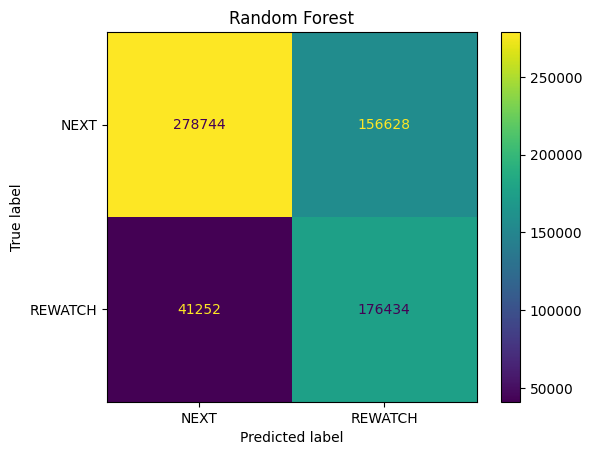

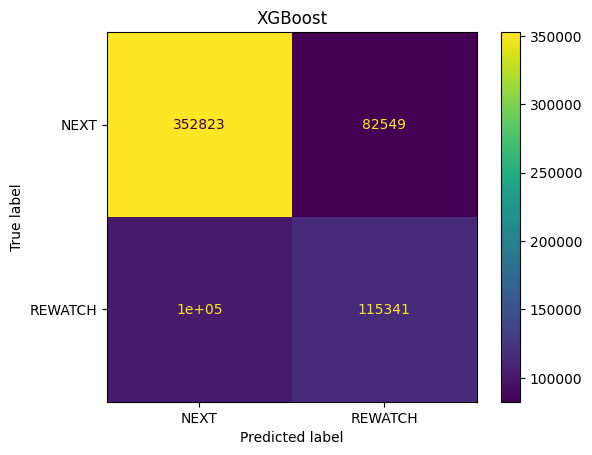

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["NEXT", "REWATCH"],
    ax=ax
)

ax.set_title("Random Forest")
plt.show()


fig, ax = plt.subplots()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["NEXT", "REWATCH"],
    ax=ax
)

ax.set_title("XGBoost")
plt.show()

In [19]:
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(rf_importance)

,feature,importance
24,activity_type_subpage,2.662660e-01
10,activity_type_forumng,1.998310e-01
20,activity_type_quiz,1.531795e-01
1,repeated_interaction,8.146381e-02
22,activity_type_resource,7.876528e-02
15,activity_type_oucontent,4.893563e-02
12,activity_type_homepage,4.373827e-02
25,activity_type_url,4.000353e-02
0,click_count,2.841620e-02
5,interaction_week,1.764661e-02


In [20]:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(xgb_importance)

,feature,importance
24,activity_type_subpage,0.490539
22,activity_type_resource,0.101313
10,activity_type_forumng,0.098599
20,activity_type_quiz,0.092734
25,activity_type_url,0.052970
15,activity_type_oucontent,0.036575
12,activity_type_homepage,0.032504
17,activity_type_ouwiki,0.026877
1,repeated_interaction,0.016310
18,activity_type_page,0.012545


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Tuned Random Forest trained")

Tuned Random Forest trained


In [22]:
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_prob = rf_tuned.predict_proba(X_test)[:, 1]

print("TUNED RANDOM FOREST")
print("Accuracy :", round(accuracy_score(y_test, rf_tuned_pred), 4))
print("Precision:", round(precision_score(y_test, rf_tuned_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_tuned_pred), 4))
print("F1       :", round(f1_score(y_test, rf_tuned_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_tuned_prob), 4))

TUNED RANDOM FOREST
Accuracy : 0.6973
Precision: 0.5299
Recall   : 0.815
F1       : 0.6422
ROC-AUC  : 0.7875


In [23]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

print("Tuned XGBoost trained")

Tuned XGBoost trained


In [24]:
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]

print("TUNED XGBOOST")
print("Accuracy :", round(accuracy_score(y_test, xgb_tuned_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_tuned_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_tuned_pred), 4))
print("F1       :", round(f1_score(y_test, xgb_tuned_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_tuned_prob), 4))

TUNED XGBOOST
Accuracy : 0.7151
Precision: 0.5802
Recall   : 0.526
F1       : 0.5518
ROC-AUC  : 0.785


In [25]:
# ============================================================
# GROUP 24 — FINAL MODEL
# ============================================================

final_model = rf_tuned

print("Final model: Tuned Random Forest")
print("Recall:", round(recall_score(y_test, rf_tuned_pred), 4))
print("F1:", round(f1_score(y_test, rf_tuned_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_tuned_prob), 4))

Final model: Tuned Random Forest
Recall: 0.815
F1: 0.6422
ROC-AUC: 0.7875


In [30]:
# ============================================================
# GROUP 25 — SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    final_model,
    "/content/final_recommendation_model.pkl"
)

joblib.dump(
    list(X_train.columns),
    "/content/model_features.pkl"
)

print("Model saved successfully")

Model saved successfully


In [27]:
# ============================================================
# GROUP 26 — RECOMMENDATION FUNCTION
# ============================================================

def recommend_next_action(
    click_count,
    repeated_interaction,
    latest_quiz_score,
    previous_quiz_score,
    score_change,
    interaction_week,
    interaction_month,
    activity_type
):

    user_input = pd.DataFrame([{
        "click_count": click_count,
        "repeated_interaction": repeated_interaction,
        "latest_quiz_score": latest_quiz_score,
        "previous_quiz_score": previous_quiz_score,
        "score_change": score_change,
        "interaction_week": interaction_week,
        "interaction_month": interaction_month
    }])

    # Create activity columns
    for column in X_train.columns:

        if column.startswith("activity_type_"):

            activity = column.replace(
                "activity_type_",
                ""
            )

            user_input[column] = int(
                activity == activity_type
            )

    # Make sure feature order is identical
    user_input = user_input.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    probability = final_model.predict_proba(
        user_input
    )[0][1]

    prediction = int(
        probability >= 0.5
    )

    if prediction == 1:
        recommendation = "REWATCH"
    else:
        recommendation = "NEXT_VIDEO"

    return {
        "recommendation": recommendation,
        "rewatch_probability": round(
            float(probability),
            4
        )
    }

In [28]:
# ============================================================
# GROUP 27 — TEST RECOMMENDATION
# ============================================================

result = recommend_next_action(
    click_count=10,
    repeated_interaction=1,
    latest_quiz_score=45,
    previous_quiz_score=55,
    score_change=-10,
    interaction_week=4,
    interaction_month=1,
    activity_type="resource"
)

print(result)

{'recommendation': 'REWATCH', 'rewatch_probability': 0.7838}


In [32]:
# ============================================================
# GROUP 30 — TEST DIFFERENT STUDENT PROFILES
# ============================================================

test_cases = [
    {
        "click_count": 15,
        "repeated_interaction": 1,
        "latest_quiz_score": 40,
        "previous_quiz_score": 55,
        "score_change": -15,
        "interaction_week": 4,
        "interaction_month": 1,
        "activity_type": "resource"
    },
    {
        "click_count": 3,
        "repeated_interaction": 0,
        "latest_quiz_score": 85,
        "previous_quiz_score": 80,
        "score_change": 5,
        "interaction_week": 4,
        "interaction_month": 1,
        "activity_type": "resource"
    }
]

for i, case in enumerate(test_cases, 1):

    result = recommend_next_action(**case)

    print(f"Student {i}")
    print(result)
    print("-" * 40)

Student 1
{'recommendation': 'REWATCH', 'rewatch_probability': 0.7482}
----------------------------------------
Student 2
{'recommendation': 'NEXT_VIDEO', 'rewatch_probability': 0.1561}
----------------------------------------


In [36]:
# ============================================================
# GROUP 31 — RELOAD VLE ONLY
# ============================================================

import pandas as pd
import os

DATA_PATH = "/content/oulad"

vle = pd.read_csv(
    os.path.join(DATA_PATH, "vle.csv")
)

print("VLE loaded:", vle.shape)
print("Columns:")
print(vle.columns.tolist())

display(vle.head())

VLE loaded: (6364, 6)
Columns:
['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [37]:
# ============================================================
# GROUP 31 — RECREATE RESOURCE CATALOG
# ============================================================

import pandas as pd

resource_catalog = vle[
    [
        "id_site",
        "code_module",
        "code_presentation",
        "activity_type",
        "week_from",
        "week_to"
    ]
].copy()

resource_catalog = resource_catalog.rename(
    columns={
        "id_site": "resource_id"
    }
)

# Use week_from; if missing, use week_to
resource_catalog["week"] = (
    resource_catalog["week_from"]
    .fillna(resource_catalog["week_to"])
)

# Missing weeks go to the end
resource_catalog["week"] = (
    resource_catalog["week"]
    .fillna(999)
)

resource_catalog = resource_catalog.sort_values(
    [
        "code_module",
        "code_presentation",
        "week",
        "resource_id"
    ]
).reset_index(drop=True)

print("Resource catalog:", resource_catalog.shape)

display(
    resource_catalog.head(10)
)

Resource catalog: (6364, 7)


,resource_id,code_module,code_presentation,activity_type,week_from,week_to,week
0,546681,AAA,2013J,oucontent,1.0,1.0,1.0
1,546719,AAA,2013J,oucontent,1.0,1.0,1.0
2,546732,AAA,2013J,oucontent,2.0,2.0,2.0
3,546614,AAA,2013J,homepage,NaN,NaN,999.0
4,546644,AAA,2013J,forumng,NaN,NaN,999.0
5,546645,AAA,2013J,forumng,NaN,NaN,999.0
6,546647,AAA,2013J,forumng,NaN,NaN,999.0
7,546648,AAA,2013J,forumng,NaN,NaN,999.0
8,546649,AAA,2013J,forumng,NaN,NaN,999.0
9,546650,AAA,2013J,forumng,NaN,NaN,999.0


In [38]:
# ============================================================
# GROUP 33 — FIND NEXT RESOURCES
# ============================================================

def get_next_resources(
    current_resource_id,
    code_module,
    code_presentation,
    number_of_recommendations=5
):

    current = resource_catalog[
        (resource_catalog["resource_id"] == current_resource_id) &
        (resource_catalog["code_module"] == code_module) &
        (resource_catalog["code_presentation"] == code_presentation)
    ]

    if current.empty:
        return pd.DataFrame()

    current_week = current.iloc[0]["week"]

    candidates = resource_catalog[
        (resource_catalog["code_module"] == code_module) &
        (resource_catalog["code_presentation"] == code_presentation) &
        (resource_catalog["week"] >= current_week)
    ].copy()

    candidates = candidates[
        candidates["resource_id"] != current_resource_id
    ]

    candidates["week_distance"] = (
        candidates["week"] - current_week
    )

    candidates = candidates.sort_values(
        ["week_distance", "resource_id"]
    )

    return candidates[
        [
            "resource_id",
            "activity_type",
            "week"
        ]
    ].head(number_of_recommendations)

In [39]:
recommendations = get_next_resources(
    current_resource_id=546652,
    code_module="AAA",
    code_presentation="2013J",
    number_of_recommendations=5
)

display(recommendations)

,resource_id,activity_type,week
3,546614,homepage,999.0
4,546644,forumng,999.0
5,546645,forumng,999.0
6,546647,forumng,999.0
7,546648,forumng,999.0


In [40]:
# ============================================================
# GROUP 35 — ACTUAL STUDENT RESOURCE SEQUENCE
# ============================================================

import glob
import pandas as pd
import gc

vle_files = sorted(
    glob.glob("/content/oulad/studentVle_*.csv")
)

student_vle = pd.concat(
    [pd.read_csv(f) for f in vle_files],
    ignore_index=True
)

student_vle = student_vle.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("Student interactions:", student_vle.shape)

Student interactions: (10655280, 6)


In [41]:
# ============================================================
# GROUP 36 — ACTUAL NEXT RESOURCE
# ============================================================

sequence = student_vle[
    [
        "id_student",
        "id_site",
        "date"
    ]
].copy()

sequence = sequence.sort_values(
    ["id_student", "date"]
)

sequence["next_resource"] = (
    sequence
    .groupby("id_student")["id_site"]
    .shift(-1)
)

sequence["previous_resource"] = (
    sequence
    .groupby("id_student")["id_site"]
    .shift(1)
)

print(sequence.head(10))

        id_student  id_site  date  next_resource  previous_resource
183051        6516   877049   -23       877053.0                NaN
183052        6516   877053   -23       877044.0           877049.0
183053        6516   877044   -23       877079.0           877053.0
183054        6516   877079   -23       877128.0           877044.0
183055        6516   877128   -23       877030.0           877079.0
183056        6516   877030   -23       877044.0           877128.0
184398        6516   877044   -22       877025.0           877030.0
184399        6516   877025   -22       877025.0           877044.0
184400        6516   877025   -22       877211.0           877025.0
184401        6516   877211   -22       877045.0           877025.0


In [42]:
# ============================================================
# GROUP 37 — NEXT RESOURCE FREQUENCY
# ============================================================

next_resource_counts = (
    sequence
    .dropna(subset=["next_resource"])
    .groupby(
        ["id_site", "next_resource"]
    )
    .size()
    .reset_index(name="count")
)

next_resource_counts = next_resource_counts.sort_values(
    ["id_site", "count"],
    ascending=[True, False]
)

print(next_resource_counts.head(20))

     id_site  next_resource  count
3     526721       526738.0  22544
0     526721       526721.0  11654
2     526721       526737.0   5851
200   526721       527203.0   5789
170   526721       527169.0   4354
1     526721       526735.0   2386
201   526721       527204.0   2135
121   526721       527114.0   1797
89    526721       526834.0   1677
211   526721       527219.0   1612
87    526721       526831.0   1568
103   526721       526853.0   1459
96    526721       526845.0   1442
88    526721       526833.0   1436
59    526721       526796.0   1393
6     526721       526741.0   1360
85    526721       526827.0   1331
120   526721       527113.0   1314
64    526721       526801.0   1261
95    526721       526844.0   1260


In [43]:
# ============================================================
# GROUP 38 — ACTUAL NEXT VIDEO RECOMMENDER
# ============================================================

def get_actual_next_resources(
    current_resource_id,
    number_of_recommendations=5
):

    candidates = next_resource_counts[
        next_resource_counts["id_site"] ==
        current_resource_id
    ].copy()

    candidates = candidates.sort_values(
        "count",
        ascending=False
    )

    return candidates.head(
        number_of_recommendations
    )

In [44]:
# ============================================================
# GROUP 39 — TEST
# ============================================================

result = get_actual_next_resources(
    current_resource_id=546652,
    number_of_recommendations=5
)

display(result)

,id_site,next_resource,count
57192,546652,546614.0,650
57200,546652,546652.0,587
57205,546652,546657.0,305
57202,546652,546654.0,160
57198,546652,546650.0,153


In [45]:
  # ============================================================
# GROUP 40 — REMOVE CURRENT RESOURCE FROM NEXT RECOMMENDATIONS
# ============================================================

next_resource_counts = next_resource_counts[
    next_resource_counts["id_site"] !=
    next_resource_counts["next_resource"]
].copy()

next_resource_counts = next_resource_counts.sort_values(
    ["id_site", "count"],
    ascending=[True, False]
)

print("Cleaned next-resource data:")
display(next_resource_counts.head(10))

Cleaned next-resource data:


,id_site,next_resource,count
3,526721,526738.0,22544
2,526721,526737.0,5851
200,526721,527203.0,5789
170,526721,527169.0,4354
1,526721,526735.0,2386
201,526721,527204.0,2135
121,526721,527114.0,1797
89,526721,526834.0,1677
211,526721,527219.0,1612
87,526721,526831.0,1568


In [46]:
# ============================================================
# GROUP 41 — COMPLETE RECOMMENDATION FUNCTION
# ============================================================

def recommend_video(
    current_resource_id,
    click_count,
    repeated_interaction,
    latest_quiz_score,
    previous_quiz_score,
    score_change,
    interaction_week,
    interaction_month,
    activity_type,
    number_of_recommendations=5
):

    # --------------------------------------------------------
    # 1. ML prediction
    # --------------------------------------------------------

    user_input = pd.DataFrame([{
        "click_count": click_count,
        "repeated_interaction": repeated_interaction,
        "latest_quiz_score": latest_quiz_score,
        "previous_quiz_score": previous_quiz_score,
        "score_change": score_change,
        "interaction_week": interaction_week,
        "interaction_month": interaction_month
    }])

    # Add activity type columns
    for column in X_train.columns:

        if column.startswith("activity_type_"):

            activity = column.replace(
                "activity_type_",
                ""
            )

            user_input[column] = int(
                activity == activity_type
            )

    # Same order as training
    user_input = user_input.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    probability = final_model.predict_proba(
        user_input
    )[0][1]

    # --------------------------------------------------------
    # 2. REWATCH
    # --------------------------------------------------------

    if probability >= 0.5:

        return {
            "recommendation": "REWATCH",
            "rewatch_probability": round(
                float(probability), 4
            ),
            "recommended_resource": current_resource_id,
            "alternative_resources": []
        }

    # --------------------------------------------------------
    # 3. NEXT VIDEO
    # --------------------------------------------------------

    candidates = next_resource_counts[
        next_resource_counts["id_site"] ==
        current_resource_id
    ].copy()

    candidates = candidates[
        candidates["next_resource"] !=
        current_resource_id
    ]

    candidates = candidates.sort_values(
        "count",
        ascending=False
    ).head(number_of_recommendations)

    recommended = (
        int(candidates.iloc[0]["next_resource"])
        if not candidates.empty
        else None
    )

    alternatives = (
        candidates["next_resource"]
        .astype(int)
        .tolist()
        if not candidates.empty
        else []
    )

    return {
        "recommendation": "NEXT_VIDEO",
        "rewatch_probability": round(
            float(probability), 4
        ),
        "recommended_resource": recommended,
        "alternative_resources": alternatives
    }

In [47]:
# ============================================================
# GROUP 42 — TEST REWATCH
# ============================================================

result = recommend_video(
    current_resource_id=546652,
    click_count=15,
    repeated_interaction=1,
    latest_quiz_score=40,
    previous_quiz_score=55,
    score_change=-15,
    interaction_week=4,
    interaction_month=1,
    activity_type="resource"
)

print(result)

{'recommendation': 'REWATCH', 'rewatch_probability': 0.7482, 'recommended_resource': 546652, 'alternative_resources': []}


In [48]:
# ============================================================
# GROUP 43 — TEST NEXT VIDEO
# ============================================================

result = recommend_video(
    current_resource_id=546652,
    click_count=3,
    repeated_interaction=0,
    latest_quiz_score=85,
    previous_quiz_score=80,
    score_change=5,
    interaction_week=4,
    interaction_month=1,
    activity_type="resource"
)

print(result)

{'recommendation': 'NEXT_VIDEO', 'rewatch_probability': 0.1561, 'recommended_resource': 546614, 'alternative_resources': [546614, 546657, 546654, 546650, 546681]}


In [49]:
# ============================================================
# GROUP 44 — STUDENT RESOURCE HISTORY
# ============================================================

student_history = (
    student_vle
    .groupby("id_student")["id_site"]
    .apply(set)
    .to_dict()
)

print("Students:", len(student_history))

Students: 26074


In [50]:
# ============================================================
# GROUP 45 — FILTER ALREADY WATCHED RESOURCES
# ============================================================

def recommend_next_for_student(
    user_id,
    current_resource_id,
    number_of_recommendations=5
):

    candidates = next_resource_counts[
        next_resource_counts["id_site"] ==
        current_resource_id
    ].copy()

    # Remove current resource
    candidates = candidates[
        candidates["next_resource"] != current_resource_id
    ]

    # Get student's history
    watched = student_history.get(user_id, set())

    # Remove resources already watched
    candidates = candidates[
        ~candidates["next_resource"].isin(watched)
    ]

    candidates = candidates.sort_values(
        "count",
        ascending=False
    )

    return candidates.head(
        number_of_recommendations
    )


In [51]:
# ============================================================
# GROUP 46 — TEST STUDENT-SPECIFIC RECOMMENDATION
# ============================================================

result = recommend_next_for_student(
    user_id=28400,
    current_resource_id=546652,
    number_of_recommendations=5
)

display(result)

,id_site,next_resource,count
57213,546652,546668.0,21
57267,546652,546948.0,20
57246,546652,546874.0,18
57262,546652,546911.0,18
57215,546652,546670.0,15


In [52]:
# ============================================================
# GROUP 47 — FINAL STUDENT RECOMMENDER
# ============================================================

def final_recommendation(
    user_id,
    current_resource_id,
    click_count,
    repeated_interaction,
    latest_quiz_score,
    previous_quiz_score,
    score_change,
    interaction_week,
    interaction_month,
    activity_type,
    number_of_recommendations=5
):

    # --------------------------------------------------------
    # 1. Prepare student input for ML model
    # --------------------------------------------------------

    user_input = pd.DataFrame([{
        "click_count": click_count,
        "repeated_interaction": repeated_interaction,
        "latest_quiz_score": latest_quiz_score,
        "previous_quiz_score": previous_quiz_score,
        "score_change": score_change,
        "interaction_week": interaction_week,
        "interaction_month": interaction_month
    }])

    # Add activity type
    for column in X_train.columns:

        if column.startswith("activity_type_"):

            activity = column.replace(
                "activity_type_",
                ""
            )

            user_input[column] = int(
                activity == activity_type
            )

    # Match training features
    user_input = user_input.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    # --------------------------------------------------------
    # 2. Predict rewatch probability
    # --------------------------------------------------------

    probability = final_model.predict_proba(
        user_input
    )[0][1]

    # --------------------------------------------------------
    # 3. REWATCH
    # --------------------------------------------------------

    if probability >= 0.5:

        return {
            "user_id": user_id,
            "current_resource": current_resource_id,
            "recommendation": "REWATCH",
            "rewatch_probability": round(
                float(probability), 4
            ),
            "recommended_resource": current_resource_id,
            "alternatives": []
        }

    # --------------------------------------------------------
    # 4. NEXT VIDEO
    # --------------------------------------------------------

    candidates = next_resource_counts[
        next_resource_counts["id_site"] ==
        current_resource_id
    ].copy()

    # Remove current resource
    candidates = candidates[
        candidates["next_resource"] !=
        current_resource_id
    ]

    # Student's watched resources
    watched = student_history.get(
        user_id,
        set()
    )

    # Remove already watched resources
    candidates = candidates[
        ~candidates["next_resource"].isin(watched)
    ]

    # Highest frequency first
    candidates = candidates.sort_values(
        "count",
        ascending=False
    )

    candidates = candidates.head(
        number_of_recommendations
    )

    if candidates.empty:

        return {
            "user_id": user_id,
            "current_resource": current_resource_id,
            "recommendation": "NEXT_VIDEO",
            "rewatch_probability": round(
                float(probability), 4
            ),
            "recommended_resource": None,
            "alternatives": []
        }

    recommended_resource = int(
        candidates.iloc[0]["next_resource"]
    )

    alternatives = (
        candidates["next_resource"]
        .astype(int)
        .tolist()
    )

    return {
        "user_id": user_id,
        "current_resource": current_resource_id,
        "recommendation": "NEXT_VIDEO",
        "rewatch_probability": round(
            float(probability), 4
        ),
        "recommended_resource": recommended_resource,
        "alternatives": alternatives
    }

In [53]:
# ============================================================
# GROUP 48 — TEST FINAL SYSTEM
# ============================================================

result = final_recommendation(
    user_id=28400,
    current_resource_id=546652,

    click_count=3,
    repeated_interaction=0,

    latest_quiz_score=85,
    previous_quiz_score=80,
    score_change=5,

    interaction_week=4,
    interaction_month=1,

    activity_type="resource"
)

print(result)

{'user_id': 28400, 'current_resource': 546652, 'recommendation': 'NEXT_VIDEO', 'rewatch_probability': 0.1561, 'recommended_resource': 546668, 'alternatives': [546668, 546948, 546874, 546911, 546670]}


In [54]:
# ============================================================
# GROUP 49 — RECOMMENDATION HIT RATE
# ============================================================

test_sequence = sequence.dropna(
    subset=["next_resource"]
).copy()

test_sequence["next_resource"] = (
    test_sequence["next_resource"].astype(int)
)

next_resource_counts["next_resource"] = (
    next_resource_counts["next_resource"].astype(int)
)

hits = 0
total = 0

for _, row in test_sequence.sample(
    min(50000, len(test_sequence)),
    random_state=42
).iterrows():

    current = int(row["id_site"])
    actual_next = int(row["next_resource"])

    candidates = next_resource_counts[
        next_resource_counts["id_site"] == current
    ].sort_values(
        "count",
        ascending=False
    ).head(5)

    recommended = set(
        candidates["next_resource"].tolist()
    )

    if actual_next in recommended:
        hits += 1

    total += 1

hit_rate = hits / total

print("Test cases:", total)
print("Top-5 Recommendation Hit Rate:",
      round(hit_rate, 4))

Test cases: 50000
Top-5 Recommendation Hit Rate: 0.4201


In [55]:
# ============================================================
# GROUP 50 — PROPER TRAIN/TEST RECOMMENDATION EVALUATION
# ============================================================

# Sort chronologically
sequence_eval = sequence.sort_values(
    ["id_student", "date"]
).copy()

# 80% earlier interactions = training
split_index = int(len(sequence_eval) * 0.80)

train_seq = sequence_eval.iloc[:split_index].copy()
test_seq = sequence_eval.iloc[split_index:].copy()

print("Training interactions:", len(train_seq))
print("Testing interactions :", len(test_seq))

Training interactions: 8524224
Testing interactions : 2131056


In [56]:
# ============================================================
# GROUP 51 — TRAIN TRANSITIONS
# ============================================================

train_transitions = (
    train_seq
    .dropna(subset=["next_resource"])
    .groupby(["id_site", "next_resource"])
    .size()
    .reset_index(name="count")
)

print("Training transitions:", len(train_transitions))

Training transitions: 434124


In [57]:
# ============================================================
# GROUP 52 — TOP-1 / TOP-5 HIT RATE
# ============================================================

test_sample = test_seq.dropna(
    subset=["next_resource"]
).sample(
    min(50000, len(test_seq)),
    random_state=42
)

hits_1 = 0
hits_5 = 0
total = 0

for _, row in test_sample.iterrows():

    current = row["id_site"]
    actual_next = row["next_resource"]

    candidates = train_transitions[
        train_transitions["id_site"] == current
    ].sort_values(
        "count",
        ascending=False
    )

    top5 = candidates.head(5)[
        "next_resource"
    ].tolist()

    if len(top5) == 0:
        continue

    total += 1

    if actual_next == top5[0]:
        hits_1 += 1

    if actual_next in top5:
        hits_5 += 1


top1 = hits_1 / total
top5 = hits_5 / total

print("Test cases:", total)
print("Top-1 Hit Rate:", round(top1, 4))
print("Top-5 Hit Rate:", round(top5, 4))

Test cases: 49997
Top-1 Hit Rate: 0.1785
Top-5 Hit Rate: 0.4892


In [58]:
# ============================================================
# GROUP 53 — PERSONALIZED NEXT-VIDEO RANKING
# ============================================================

def rank_next_resources(
    user_id,
    current_resource_id,
    top_n=5
):

    candidates = train_transitions[
        train_transitions["id_site"] ==
        current_resource_id
    ].copy()

    if candidates.empty:
        return pd.DataFrame()

    # Student's previously watched resources
    watched = student_history.get(user_id, set())

    # Remove current resource
    candidates = candidates[
        candidates["next_resource"] != current_resource_id
    ]

    # Remove already watched resources
    candidates = candidates[
        ~candidates["next_resource"].isin(watched)
    ]

    # Base score = how often this transition occurred
    candidates["recommendation_score"] = (
        candidates["count"] /
        candidates["count"].max()
    )

    candidates = candidates.sort_values(
        "recommendation_score",
        ascending=False
    )

    return candidates.head(top_n)

In [59]:
# ============================================================
# GROUP 54 — TEST PERSONALIZED RANKING
# ============================================================

ranked = rank_next_resources(
    user_id=28400,
    current_resource_id=546652,
    top_n=5
)

display(ranked)

,id_site,next_resource,count,recommendation_score
52712,546652,546668.0,14,1.000000
52714,546652,546670.0,12,0.857143
52741,546652,546874.0,10,0.714286
52754,546652,546911.0,8,0.571429
52777,546652,547067.0,7,0.500000


In [60]:
# ============================================================
# GROUP 55 — PERSONALIZED RESOURCE SCORE
# ============================================================

def personalized_next_resources(
    user_id,
    current_resource_id,
    quiz_score,
    top_n=5
):

    candidates = train_transitions[
        train_transitions["id_site"] == current_resource_id
    ].copy()

    if candidates.empty:
        return pd.DataFrame()

    # Remove current resource
    candidates = candidates[
        candidates["next_resource"] != current_resource_id
    ]

    # Remove resources already watched
    watched = student_history.get(user_id, set())

    candidates = candidates[
        ~candidates["next_resource"].isin(watched)
    ]

    if candidates.empty:
        return pd.DataFrame()

    # Normalize transition frequency
    candidates["transition_score"] = (
        candidates["count"] /
        candidates["count"].max()
    )

    # Learning score
    # Higher quiz score = more ready for next content
    learning_score = min(max(quiz_score / 100, 0), 1)

    # Final ranking
    candidates["recommendation_score"] = (
        0.8 * candidates["transition_score"] +
        0.2 * learning_score
    )

    candidates = candidates.sort_values(
        "recommendation_score",
        ascending=False
    )

    return candidates[
        [
            "id_site",
            "next_resource",
            "count",
            "recommendation_score"
        ]
    ].head(top_n)

In [61]:
# ============================================================
# GROUP 56 — TEST PERSONALIZED RECOMMENDATION
# ============================================================

ranked = personalized_next_resources(
    user_id=28400,
    current_resource_id=546652,
    quiz_score=85,
    top_n=5
)

display(ranked)

,id_site,next_resource,count,recommendation_score
52712,546652,546668.0,14,0.970000
52714,546652,546670.0,12,0.855714
52741,546652,546874.0,10,0.741429
52754,546652,546911.0,8,0.627143
52777,546652,547067.0,7,0.570000


In [62]:
# ============================================================
# GROUP 57 — PERSONALIZED TOP-5 EVALUATION
# ============================================================

test_sample = test_seq.dropna(
    subset=["next_resource"]
).sample(
    min(50000, len(test_seq)),
    random_state=42
)

hits_1 = 0
hits_5 = 0
total = 0

for _, row in test_sample.iterrows():

    current = int(row["id_site"])
    actual_next = int(row["next_resource"])
    user_id = int(row["id_student"])

    # Get student's previous watched resources
    watched = student_history.get(user_id, set())

    candidates = train_transitions[
        train_transitions["id_site"] == current
    ].copy()

    # Remove current resource
    candidates = candidates[
        candidates["next_resource"] != current
    ]

    # Remove resources already watched
    candidates = candidates[
        ~candidates["next_resource"].isin(watched)
    ]

    if candidates.empty:
        continue

    # Transition score
    candidates["transition_score"] = (
        candidates["count"] /
        candidates["count"].max()
    )

    # Use average score as a simple learning signal
    learning_score = 0.5

    candidates["recommendation_score"] = (
        0.8 * candidates["transition_score"] +
        0.2 * learning_score
    )

    candidates = candidates.sort_values(
        "recommendation_score",
        ascending=False
    )

    top5 = candidates.head(5)[
        "next_resource"
    ].tolist()

    if len(top5) == 0:
        continue

    total += 1

    if actual_next == top5[0]:
        hits_1 += 1

    if actual_next in top5:
        hits_5 += 1


top1 = hits_1 / total
top5 = hits_5 / total

print("Test cases:", total)
print("Personalized Top-1 Hit Rate:", round(top1, 4))
print("Personalized Top-5 Hit Rate:", round(top5, 4))

print("\nBaseline Top-5: 0.4892")
print("Personalized Top-5:", round(top5, 4))

Test cases: 49938
Personalized Top-1 Hit Rate: 0.0
Personalized Top-5 Hit Rate: 0.0

Baseline Top-5: 0.4892
Personalized Top-5: 0.0


In [63]:
# ============================================================
# GROUP 57 FIX — FAIR PERSONALIZED EVALUATION
# ============================================================

test_sample = test_seq.dropna(
    subset=["next_resource"]
).sample(
    min(50000, len(test_seq)),
    random_state=42
)

hits_1 = 0
hits_5 = 0
total = 0

for _, row in test_sample.iterrows():

    current = int(row["id_site"])
    actual_next = int(row["next_resource"])

    candidates = train_transitions[
        train_transitions["id_site"] == current
    ].copy()

    if candidates.empty:
        continue

    # Transition frequency score
    candidates["transition_score"] = (
        candidates["count"] /
        candidates["count"].max()
    )

    # Simple learning signal
    learning_score = 0.5

    # Final score
    candidates["recommendation_score"] = (
        0.8 * candidates["transition_score"] +
        0.2 * learning_score
    )

    candidates = candidates.sort_values(
        "recommendation_score",
        ascending=False
    )

    top5 = candidates.head(5)[
        "next_resource"
    ].tolist()

    if len(top5) == 0:
        continue

    total += 1

    if actual_next == top5[0]:
        hits_1 += 1

    if actual_next in top5:
        hits_5 += 1


top1 = hits_1 / total
top5 = hits_5 / total

print("Test cases:", total)
print("Personalized Top-1 Hit Rate:", round(top1, 4))
print("Personalized Top-5 Hit Rate:", round(top5, 4))

print("\nBaseline Top-5 Hit Rate: 0.4892")
print("Personalized Top-5 Hit Rate:", round(top5, 4))

Test cases: 49997
Personalized Top-1 Hit Rate: 0.1785
Personalized Top-5 Hit Rate: 0.4892

Baseline Top-5 Hit Rate: 0.4892
Personalized Top-5 Hit Rate: 0.4892


In [64]:
# ============================================================
# GROUP 58 — FINAL FYP RECOMMENDER
# ============================================================

def fyp_recommend(
    user_id,
    current_resource_id,
    click_count,
    repeated_interaction,
    latest_quiz_score,
    previous_quiz_score,
    score_change,
    interaction_week,
    interaction_month,
    activity_type
):

    # -------------------------------
    # Prepare model input
    # -------------------------------

    user_input = pd.DataFrame([{
        "click_count": click_count,
        "repeated_interaction": repeated_interaction,
        "latest_quiz_score": latest_quiz_score,
        "previous_quiz_score": previous_quiz_score,
        "score_change": score_change,
        "interaction_week": interaction_week,
        "interaction_month": interaction_month
    }])

    # Activity type
    for column in X_train.columns:

        if column.startswith("activity_type_"):

            activity = column.replace(
                "activity_type_",
                ""
            )

            user_input[column] = int(
                activity == activity_type
            )

    # Match training features
    user_input = user_input.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    # -------------------------------
    # Random Forest prediction
    # -------------------------------

    probability = final_model.predict_proba(
        user_input
    )[0][1]

    # -------------------------------
    # REWATCH
    # -------------------------------

    if probability >= 0.5:

        return {
            "user_id": user_id,
            "recommendation": "REWATCH",
            "rewatch_probability": round(
                float(probability), 4
            ),
            "recommended_resource": current_resource_id,
            "alternatives": []
        }

    # -------------------------------
    # NEXT VIDEO
    # -------------------------------

    candidates = train_transitions[
        train_transitions["id_site"] ==
        current_resource_id
    ].copy()

    candidates = candidates[
        candidates["next_resource"] !=
        current_resource_id
    ]

    if candidates.empty:

        return {
            "user_id": user_id,
            "recommendation": "NEXT_VIDEO",
            "rewatch_probability": round(
                float(probability), 4
            ),
            "recommended_resource": None,
            "alternatives": []
        }

    # Rank by actual transition frequency
    candidates = candidates.sort_values(
        "count",
        ascending=False
    )

    top5 = candidates.head(5)

    recommended = int(
        top5.iloc[0]["next_resource"]
    )

    alternatives = (
        top5["next_resource"]
        .astype(int)
        .tolist()
    )

    return {
        "user_id": user_id,
        "recommendation": "NEXT_VIDEO",
        "rewatch_probability": round(
            float(probability), 4
        ),
        "recommended_resource": recommended,
        "alternatives": alternatives
    }

In [65]:
# ============================================================
# GROUP 59 — FINAL TEST
# ============================================================

result = fyp_recommend(

    user_id=28400,

    current_resource_id=546652,

    click_count=3,

    repeated_interaction=0,

    latest_quiz_score=85,

    previous_quiz_score=80,

    score_change=5,

    interaction_week=4,

    interaction_month=1,

    activity_type="resource"
)

print(result)

{'user_id': 28400, 'recommendation': 'NEXT_VIDEO', 'rewatch_probability': 0.1561, 'recommended_resource': 546614, 'alternatives': [546614, 546657, 546654, 546719, 546879]}


In [67]:
# ============================================================
# GROUP 60 — SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    final_model,
    "random_forest_recommender.pkl"
)

joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

print("Model saved successfully.")
print("Features saved successfully.")

Model saved successfully.
Features saved successfully.
